In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style uniforme pour toutes les figures du rapport
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# --- Chargement ---
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("=" * 50)
print(f"Shape : {df.shape}")
print("=" * 50)
print(df.dtypes)
print("=" * 50)
print(df.head(3))

Shape : (7043, 21)
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... De

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


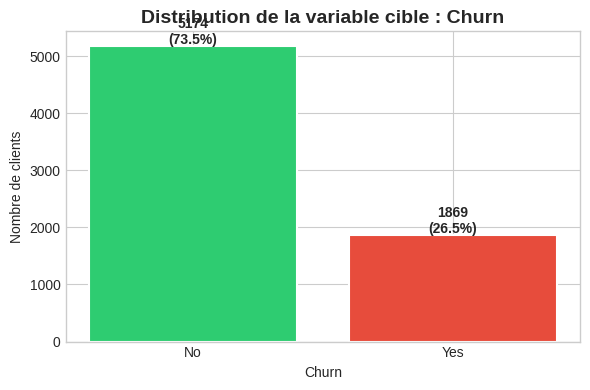

In [ ]:
# Distribution de la variable cible
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print(churn_counts)
print(churn_pct.round(2))

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(churn_counts.index, churn_counts.values,
              color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)

for bar, val, pct in zip(bars, churn_counts.values, churn_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val}\n({pct:.1f}%)', ha='center', fontweight='bold')

ax.set_title('Distribution de la variable cible : Churn', fontsize=14, fontweight='bold')
ax.set_xlabel('Churn')
ax.set_ylabel('Nombre de clients')
plt.tight_layout()
plt.savefig('01_churn_distribution.png', dpi=150)
plt.show()

In [ ]:
# Détection des valeurs manquantes explicites
print("Valeurs manquantes explicites :")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Le bug caché : TotalCharges contient des espaces
print("\n--- Bug caché ---")
print(f"Type de TotalCharges : {df['TotalCharges'].dtype}")

# Conversion forcée — les espaces deviennent NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f"Valeurs NaN après conversion : {df['TotalCharges'].isnull().sum()}")
print("\nProfil des lignes problématiques :")
print(df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']].head())

Valeurs manquantes explicites :
Series([], dtype: int64)

--- Bug caché ---
Type de TotalCharges : object
Valeurs NaN après conversion : 11

Profil des lignes problématiques :
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN


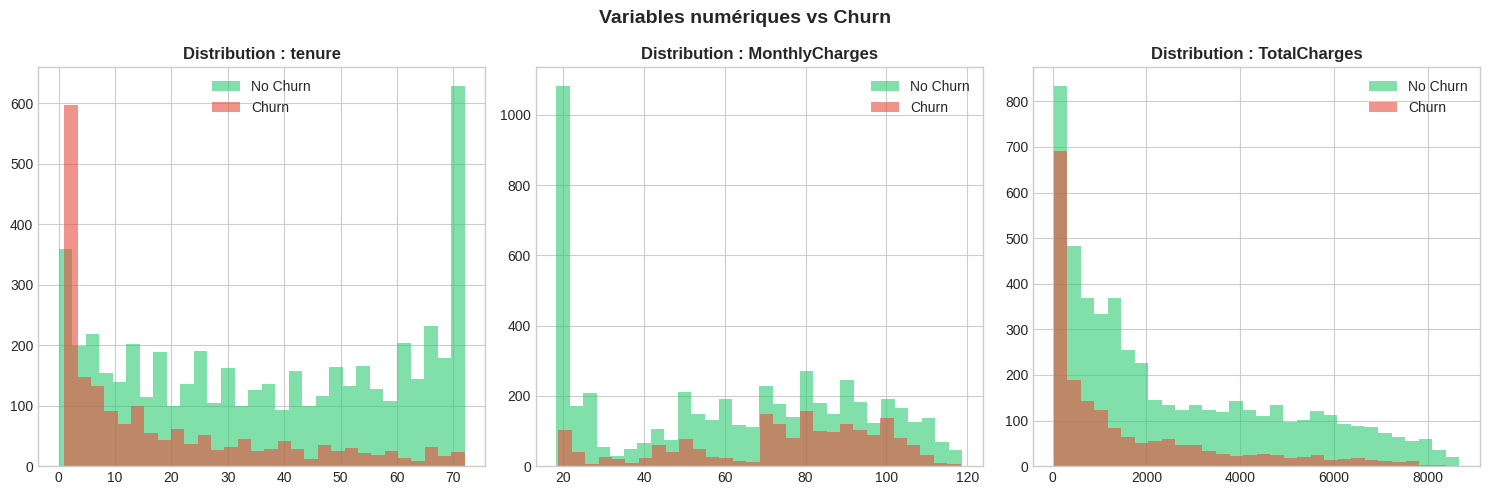

In [ ]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(num_cols):
    axes[i].hist(df[df['Churn']=='No'][col].dropna(), bins=30,
                 alpha=0.6, label='No Churn', color='#2ecc71')
    axes[i].hist(df[df['Churn']=='Yes'][col].dropna(), bins=30,
                 alpha=0.6, label='Churn', color='#e74c3c')
    axes[i].set_title(f'Distribution : {col}', fontweight='bold')
    axes[i].legend()

plt.suptitle('Variables numériques vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_numeric_distributions.png', dpi=150)
plt.show()

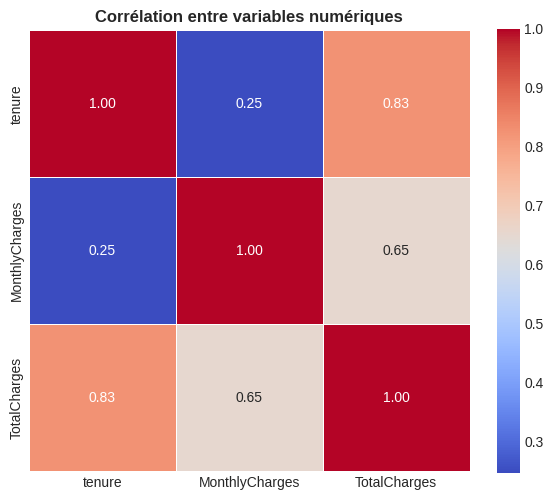

In [ ]:
# ============================================================
# BLOC 4 — Matrice de corrélation
# ============================================================
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, square=True, linewidths=0.5)
ax.set_title('Corrélation entre variables numériques', fontweight='bold')
plt.tight_layout()
plt.savefig("03_correlation_matrix.png", dpi=150)
plt.show()

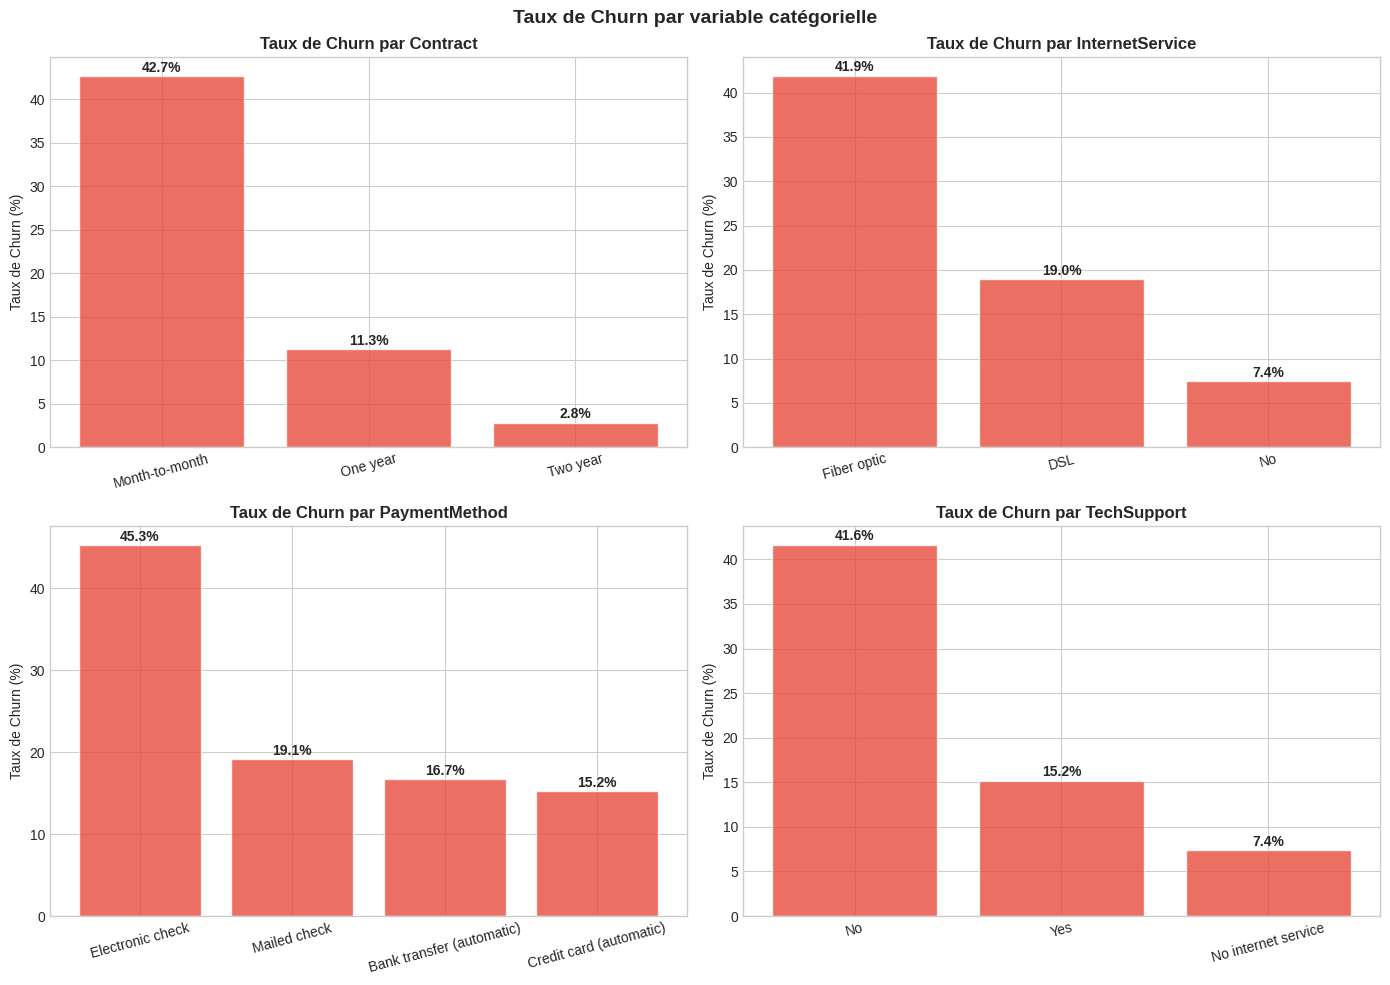

In [ ]:
# ============================================================
# BLOC 5 — Variables catégorielles clés
# ============================================================
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).reset_index()
    churn_rate.columns = [col, 'ChurnRate']
    churn_rate = churn_rate.sort_values('ChurnRate', ascending=False)

    bars = axes[i].bar(churn_rate[col], churn_rate['ChurnRate'],
                       color='#e74c3c', alpha=0.8, edgecolor='white')
    for bar, val in zip(bars, churn_rate['ChurnRate']):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

    axes[i].set_title(f'Taux de Churn par {col}', fontweight='bold', fontsize=12)
    axes[i].set_ylabel('Taux de Churn (%)')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Taux de Churn par variable catégorielle', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("04_categorical_churn_rates.png", dpi=150)
plt.show()

In [ ]:
# ============================================================
# BLOC 6 — Résumé statistique final
# ============================================================
print("=" * 55)
print("📋 RÉSUMÉ EDA — CONCLUSIONS POUR LE RAPPORT")
print("=" * 55)

churners = df[df['Churn'] == 'Yes']
non_churners = df[df['Churn'] == 'No']

print(f"\n📌 Dataset : {df.shape[0]} clients, {df.shape[1]} features")
print(f"📌 Taux de churn global : {(df['Churn']=='Yes').mean()*100:.1f}%")
print(f"\n📌 Ancienneté moyenne :")
print(f"   Churners     : {churners['tenure'].mean():.1f} mois")
print(f"   Non-churners : {non_churners['tenure'].mean():.1f} mois")
print(f"\n📌 Facture mensuelle moyenne :")
print(f"   Churners     : {churners['MonthlyCharges'].mean():.1f} $")
print(f"   Non-churners : {non_churners['MonthlyCharges'].mean():.1f} $")
print(f"\n📌 Valeurs manquantes dans TotalCharges : {df['TotalCharges'].isnull().sum()}")
print(f"   → Clients avec tenure=0 (nouveaux clients)")
print("\n✅ EDA terminée — figures sauvegardées dans /figures")

📋 RÉSUMÉ EDA — CONCLUSIONS POUR LE RAPPORT

📌 Dataset : 7043 clients, 21 features
📌 Taux de churn global : 26.5%

📌 Ancienneté moyenne :
   Churners     : 18.0 mois
   Non-churners : 37.6 mois

📌 Facture mensuelle moyenne :
   Churners     : 74.4 $
   Non-churners : 61.3 $

📌 Valeurs manquantes dans TotalCharges : 11
   → Clients avec tenure=0 (nouveaux clients)

✅ EDA terminée — figures sauvegardées dans /figures
